In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib
from xgboost import XGBRegressor

In [5]:
df = pd.read_csv("cars.csv")

In [6]:
df['Brand'].unique()

array(['Toyota', 'Honda', 'Ford', 'Maruti', 'Hyundai', 'Tata', 'Mahindra',
       'Volkswagen', 'Audi', 'BMW', 'Mercedes'], dtype=object)

In [7]:
df.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Car_ID             100 non-null    int64 
 1   Brand              100 non-null    object
 2   Model              100 non-null    object
 3   Year               100 non-null    int64 
 4   Kilometers_Driven  100 non-null    int64 
 5   Fuel_Type          100 non-null    object
 6   Transmission       100 non-null    object
 7   Owner_Type         100 non-null    object
 8   Mileage            100 non-null    int64 
 9   Engine             100 non-null    int64 
 10  Power              100 non-null    int64 
 11  Seats              100 non-null    int64 
 12  Price              100 non-null    int64 
dtypes: int64(8), object(5)
memory usage: 10.3+ KB


In [9]:
df.shape

(100, 13)

In [10]:
df.columns = df.columns.str.lower().str.strip()

df = df.dropna(subset=["price"])

# Fill missing values in numeric and categorical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [11]:
current_year = pd.to_datetime("today").year
df["car_age"] = current_year - df["year"]
df.drop(columns=["year"], inplace=True)
print(f"✅ Converted 'year' -> 'car_age' using current_year = {current_year}.")

✅ Converted 'year' -> 'car_age' using current_year = 2026.


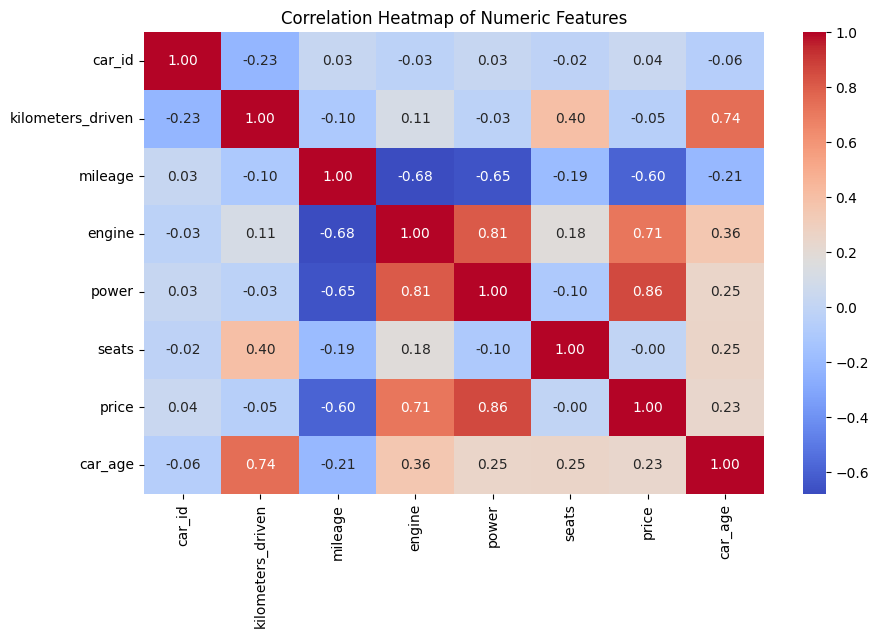

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

C:\Users\keval\AppData\Local\Temp\ipykernel_14316\1295583206.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price.index, y=avg_price.values, palette="viridis")


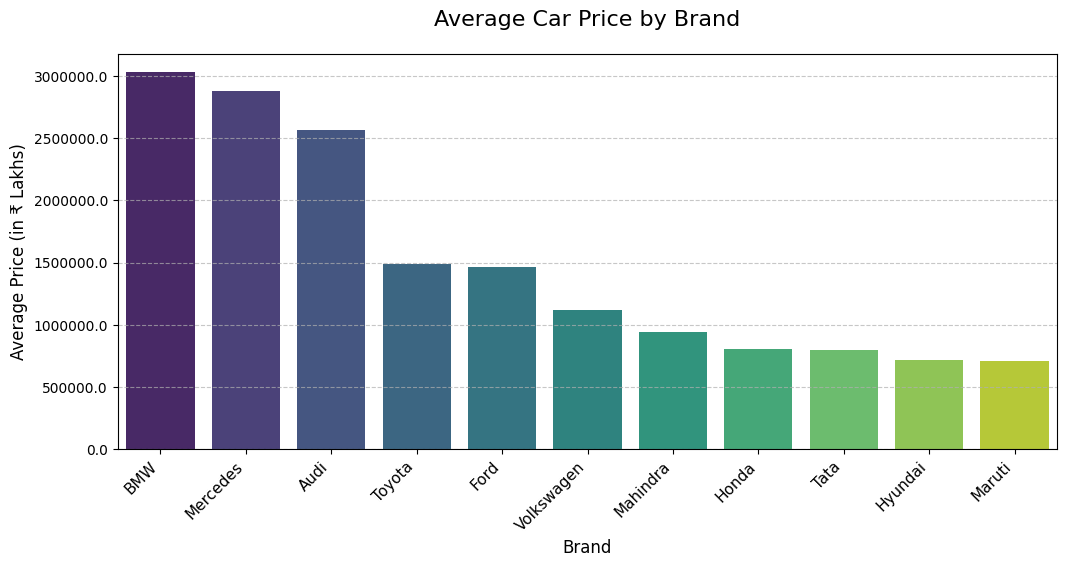

In [13]:
import matplotlib.ticker as mticker

avg_price = df.groupby("brand")["price"].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 7)) 
sns.barplot(x=avg_price.index, y=avg_price.values, palette="viridis")
plt.title("Average Car Price by Brand", fontsize=16, pad=20)
plt.xlabel("Brand", fontsize=12)
plt.ylabel("Average Price (in ₹ Lakhs)", fontsize=12)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}"))
plt.xticks(rotation=45, ha="right", fontsize=11)
plt.tight_layout(pad=5.5)  
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

C:\Users\keval\AppData\Local\Temp\ipykernel_14316\3494057283.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="fuel_type", y="price", data=df, estimator=np.mean, palette="coolwarm")


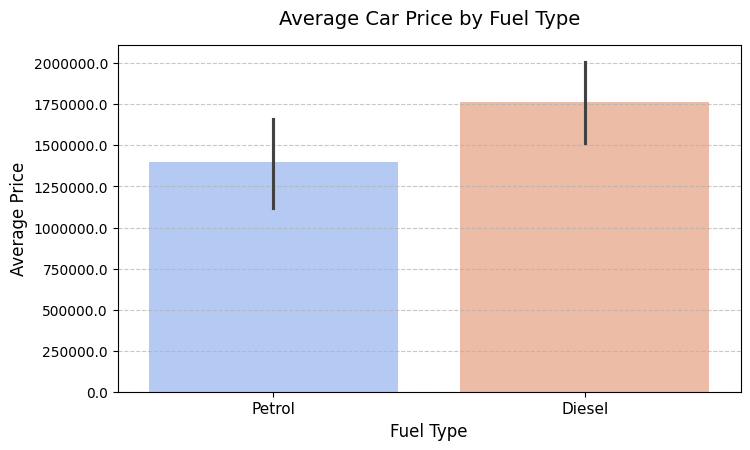

In [14]:
plt.figure(figsize=(8,5))
sns.barplot(x="fuel_type", y="price", data=df, estimator=np.mean, palette="coolwarm")
plt.title("Average Car Price by Fuel Type", fontsize=14, pad=15)
plt.xlabel("Fuel Type", fontsize=12)
plt.ylabel("Average Price", fontsize=12)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}"))
plt.xticks(rotation=0, fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout(pad=2.5)
plt.show()

In [15]:
label_enc = LabelEncoder()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in cat_cols:
    df[col] = df[col].astype(str)
    df[col] = label_enc.fit_transform(df[col])

print("✅ Encoded categorical columns successfully.")
print(df.head())

✅ Encoded categorical columns successfully.
   car_id  brand  model  kilometers_driven  fuel_type  transmission  \
0       1      9     15              50000          1             1   
1       2      3     14              40000          1             0   
2       3      2     30              20000          1             0   
3       4      6     42              30000          0             1   
4       5      4     41              60000          0             0   

   owner_type  mileage  engine  power  seats    price  car_age  
0           0       15    1498    108      5   800000        8  
1           1       17    1597    140      5  1000000        7  
2           0       10    4951    395      4  2500000        9  
3           2       23    1248     74      5   600000        6  
4           1       18    1999    194      5   850000       10  


In [16]:
X = df.drop(columns=["price"])
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


================= MODEL ACCURACY (R² Score) =================

Linear Regression:
Training Accuracy (R²): 0.8598
Testing Accuracy (R²):  0.7381
MAE: 365068.80
MSE: 214186032536.30
RMSE: 462802.37

Random Forest:
Training Accuracy (R²): 0.9918
Testing Accuracy (R²):  0.8386
MAE: 194312.50
MSE: 132040903125.00
RMSE: 363374.33

XGBoost:
Training Accuracy (R²): 1.0000
Testing Accuracy (R²):  0.9056
MAE: 136625.48
MSE: 77221322752.00
RMSE: 277887.25

====================== Model Comparison ======================
                   Train_R2   Test_R2            MAE           MSE  \
Linear Regression  0.859821  0.738111  365068.802249  2.141860e+11   
Random Forest      0.991769  0.838551  194312.500000  1.320409e+11   
XGBoost            1.000000  0.905580  136625.484375  7.722132e+10   

                            RMSE  
Linear Regression  462802.368767  
Random Forest      363374.329205  
XGBoost            277887.248272  


<Figure size 800x500 with 0 Axes>

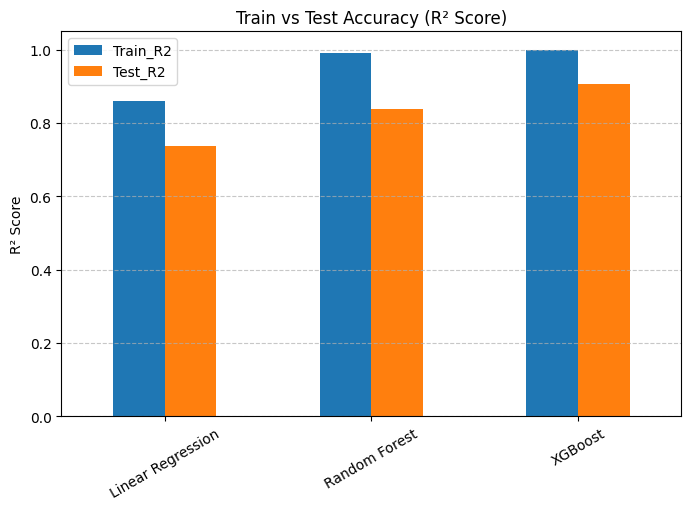

In [17]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
}

results = {}

print("\n================= MODEL ACCURACY (R² Score) =================")
for name, model in models.items():
    model.fit(X_train_scaled, y_train)

    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    # Accuracy
    train_acc = r2_score(y_train, y_train_pred)
    test_acc = r2_score(y_test, y_test_pred)

    # Error metrics
    mae = mean_absolute_error(y_test, y_test_pred)
    mse = mean_squared_error(y_test, y_test_pred)
    rmse = np.sqrt(mse)

    results[name] = [train_acc, test_acc, mae, mse, rmse]

    print(f"\n{name}:")
    print(f"Training Accuracy (R²): {train_acc:.4f}")
    print(f"Testing Accuracy (R²):  {test_acc:.4f}")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")

comparison_df = pd.DataFrame(
    results,
    index=["Train_R2", "Test_R2", "MAE", "MSE", "RMSE"]
).T

print("\n====================== Model Comparison ======================")
print(comparison_df)

plt.figure(figsize=(8,5))
comparison_df[["Train_R2", "Test_R2"]].plot(kind='bar', figsize=(8,5))
plt.title("Train vs Test Accuracy (R² Score)")
plt.ylabel("R² Score")
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [18]:
best_model_name = comparison_df["Test_R2"].idxmax()
best_model = models[best_model_name]

joblib.dump(best_model, "best_car_price_model.pkl")

print(f"\n✅ Best Model: {best_model_name} saved as 'best_car_price_model.pkl'")


✅ Best Model: XGBoost saved as 'best_car_price_model.pkl'
